# Olist Seller Evaluation & Channel Analysis

# Part 1 — Data Cleaning


In [1]:
import pandas as pd

In [2]:
mql = pd.read_csv("olist_marketing_qualified_leads_dataset.csv")
closed = pd.read_csv("olist_closed_deals_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")

In [3]:
print("MQL exact duplicates:", mql.duplicated().sum())
print("Closed exact duplicates:", closed.duplicated().sum())
print("Orders exact duplicates:", orders.duplicated().sum())
print("Order Items exact duplicates:", order_items.duplicated().sum())
print("Sellers exact duplicates:", sellers.duplicated().sum())
print("Customers exact duplicates:", customers.duplicated().sum())
print("Reviews exact duplicates:", reviews.duplicated().sum())

MQL exact duplicates: 0
Closed exact duplicates: 0
Orders exact duplicates: 0
Order Items exact duplicates: 0
Sellers exact duplicates: 0
Customers exact duplicates: 0
Reviews exact duplicates: 0


In [4]:
print("Duplicate review order IDs:",reviews["order_id"].duplicated().sum())

Duplicate review order IDs: 551


In [5]:
print("Duplicate order_id + order_item_id:",order_items[["order_id", "order_item_id"]].duplicated().sum())


Duplicate order_id + order_item_id: 0


In [6]:
mql["first_contact_date"] = pd.to_datetime(mql["first_contact_date"])
closed["won_date"] = pd.to_datetime(closed["won_date"])
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

In [7]:
orders["order_status"] == "delivered"

0        True
1        True
2        True
3        True
4        True
         ... 
99436    True
99437    True
99438    True
99439    True
99440    True
Name: order_status, Length: 99441, dtype: bool

In [8]:
review_by_order = (reviews.groupby("order_id")["review_score"].mean().reset_index())

In [9]:
#more than 1  id bec review = 1=2  2=8
review_by_order

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0
...,...,...
98668,fffc94f6ce00a00581880bf54a75a037,5.0
98669,fffcd46ef2263f404302a634eb57f7eb,5.0
98670,fffce4705a9662cd70adb13d4a31832d,5.0
98671,fffe18544ffabc95dfada21779c9644f,5.0


In [10]:
print(review_by_order.shape)
print("Duplicate order IDs:", review_by_order["order_id"].duplicated().sum())

(98673, 2)
Duplicate order IDs: 0


In [11]:
delivered_orders = orders[orders["order_status"] == "delivered"].copy()

In [12]:
delivered_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


In [13]:
#removing rows without date of delivery 
delivered_orders = delivered_orders.dropna(subset=["order_delivered_customer_date"]).copy()

In [14]:
delivered_orders["delivery_days"] = (delivered_orders["order_delivered_customer_date"]- delivered_orders["order_purchase_timestamp"]).dt.days

In [15]:
delivered_orders["delivery_days"].describe()

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

In [16]:
#build and validate seller orders

In [17]:
seller_order_level_all = (order_items.groupby(["seller_id", "order_id"]).agg(order_value=("price", "sum"),freight_value=("freight_value", "sum"),item_count=("order_item_id", "count")).reset_index())


In [18]:
print("Seller-order rows:",seller_order_level_all.shape)

print("Duplicate seller-order combinations:",seller_order_level_all[["seller_id", "order_id"]].duplicated().sum())

Seller-order rows: (100010, 5)
Duplicate seller-order combinations: 0


In [19]:
seller_order_level_all = seller_order_level_all.merge(orders[["order_id","customer_id","order_status","order_purchase_timestamp","order_delivered_customer_date","order_estimated_delivery_date"]],on="order_id",how="left")
#seller-order rows left

In [20]:
print("Seller-order rows after orders merge:",len(seller_order_level_all))
print("Missing order status:",seller_order_level_all["order_status"].isna().sum())

Seller-order rows after orders merge: 100010
Missing order status: 0


In [21]:
seller_order_level_all = seller_order_level_all.merge(review_by_order,on="order_id",how="left")

In [22]:
print("Rows after review merge:",len(seller_order_level_all))

print("Missing review scores:",seller_order_level_all["review_score"].isna().sum())

Rows after review merge: 100010
Missing review scores: 763


In [23]:
seller_order_level_all = seller_order_level_all.merge(sellers,on="seller_id",how="left")

In [24]:
print("Rows after seller merge:",len(seller_order_level_all))

print("Missing seller state:",seller_order_level_all["seller_state"].isna().sum())

print("Missing seller city:",seller_order_level_all["seller_city"].isna().sum())

Rows after seller merge: 100010
Missing seller state: 0
Missing seller city: 0


In [25]:
seller_order_level_delivered = seller_order_level_all[seller_order_level_all["order_status"] == "delivered"].copy()
#كم order لكل seller
# sales لكل seller
#review المرتبط بطلباته
# seller موقع

In [26]:
print("Delivered seller-order rows:",len(seller_order_level_delivered))

print("Unique delivered sellers:",seller_order_level_delivered["seller_id"].nunique())

Delivered seller-order rows: 97819
Unique delivered sellers: 2970


In [27]:
seller_summary_delivered = (seller_order_level_delivered.groupby("seller_id").agg(total_orders=("order_id", "nunique"),total_revenue=("order_value", "sum"),average_review_score=("review_score", "mean"),review_count=("review_score", "count")).reset_index())
#seller A | total_orders=3 | total_revenue=450 | average_review=4 | review_count=3

In [28]:
print("Seller summary shape:",seller_summary_delivered.shape)

print("Duplicate seller IDs:",seller_summary_delivered["seller_id"].duplicated().sum())

Seller summary shape: (2970, 5)
Duplicate seller IDs: 0


In [29]:
seller_summary_delivered = seller_summary_delivered.merge(sellers,on="seller_id",how="left")

In [30]:
print("Seller summary rows:",len(seller_summary_delivered))

print("Duplicate seller IDs:",seller_summary_delivered["seller_id"].duplicated().sum())

print("Missing seller state:",seller_summary_delivered["seller_state"].isna().sum())

print("Missing seller city:",seller_summary_delivered["seller_city"].isna().sum())

Seller summary rows: 2970
Duplicate seller IDs: 0
Missing seller state: 0
Missing seller city: 0


In [31]:
print("Minimum orders:",seller_summary_delivered["total_orders"].min())
print("Maximum orders:",seller_summary_delivered["total_orders"].max())
print("Minimum sales value:",seller_summary_delivered["total_revenue"].min())
print("Maximum sales value:",seller_summary_delivered["total_revenue"].max())
print("Minimum review score:",seller_summary_delivered["average_review_score"].min())
print("Maximum review score:",seller_summary_delivered["average_review_score"].max())

Minimum orders: 1
Maximum orders: 1819
Minimum sales value: 6.5
Maximum sales value: 226987.93
Minimum review score: 1.0
Maximum review score: 5.0


In [32]:
funnel_clean = mql.merge(closed,on="mql_id",how="left")

In [33]:
print("MQL rows:", len(mql))
print("Funnel rows:", len(funnel_clean))

MQL rows: 8000
Funnel rows: 8000


In [34]:
converted_sellers = funnel_clean[funnel_clean["seller_id"].notna()].copy()

In [35]:
print("Converted sellers:",len(converted_sellers))
print("Duplicate seller IDs:",converted_sellers["seller_id"].duplicated().sum())

Converted sellers: 842
Duplicate seller IDs: 0


In [36]:
seller_analysis = converted_sellers.merge(seller_summary_delivered,on="seller_id",how="left")

In [37]:
print("Converted sellers:",len(converted_sellers))
print("Seller analysis rows:",len(seller_analysis))
print("Duplicate seller IDs:",seller_analysis["seller_id"].duplicated().sum())

Converted sellers: 842
Seller analysis rows: 842
Duplicate seller IDs: 0


In [38]:
print("Sellers with delivered performance:",seller_analysis["total_orders"].notna().sum())
print("Sellers without delivered performance:",seller_analysis["total_orders"].isna().sum())

Sellers with delivered performance: 376
Sellers without delivered performance: 466


In [39]:
print(seller_analysis[["total_orders","total_revenue","average_review_score","seller_state"]].isna().sum())

total_orders            466
total_revenue           466
average_review_score    466
seller_state            466
dtype: int64


In [40]:
print("First MQL contact:",mql["first_contact_date"].min())
print("Last MQL contact:",mql["first_contact_date"].max())
print("First won seller:",closed["won_date"].min())
print("Last won seller:",closed["won_date"].max())
print("First order:",orders["order_purchase_timestamp"].min())
print("Last order:",orders["order_purchase_timestamp"].max())

First MQL contact: 2017-06-14 00:00:00
Last MQL contact: 2018-05-31 00:00:00
First won seller: 2017-12-05 02:00:00
Last won seller: 2018-11-14 18:04:19
First order: 2016-09-04 21:15:19
Last order: 2018-10-17 17:30:18


In [41]:
print("Missing order status after merge:",seller_order_level_all["order_status"].isna().sum())
print("Missing seller state after merge:",seller_order_level_all["seller_state"].isna().sum())
print("Missing review score after merge:",seller_order_level_all["review_score"].isna().sum())

Missing order status after merge: 0
Missing seller state after merge: 0
Missing review score after merge: 763


# Part 2 — Analysis Questions 1 to 6


In [42]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
seller_order_level=seller_order_level_all.copy()
delivered_so=seller_order_level_delivered.copy()
seller_summary=seller_summary_delivered.copy()
seller_summary["avg_order_value"]=seller_summary["total_revenue"]/seller_summary["total_orders"]


# Q1 & Q2

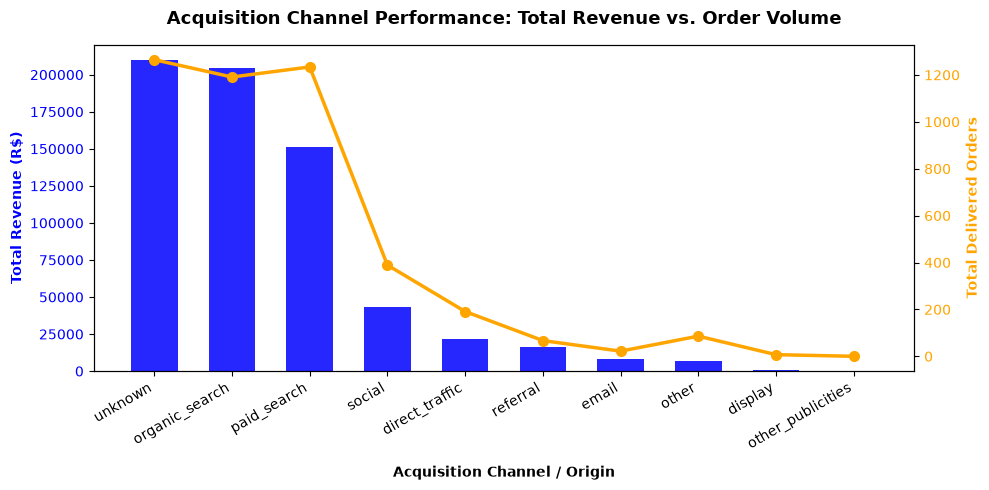

In [43]:

funnel=funnel_clean.copy()
channel_summary = (funnel.groupby("origin").agg(total_mqls=("mql_id", "count"), closed_deals=("seller_id", "count")).reset_index())

channel_sellers = funnel.dropna(subset=["seller_id"]).merge(seller_summary, on="seller_id", how="left")
channel_perf = ( channel_sellers.groupby("origin").agg(total_orders=("total_orders", "sum"),total_revenue=("total_revenue", "sum"),).reset_index())
channel_df = channel_summary.merge(channel_perf, on="origin", how="left").fillna(0)
channel_df = channel_df.sort_values(by="total_revenue", ascending=False)
fig, ax1 = plt.subplots(figsize=(10, 5))

color = "blue"
ax1.set_xlabel("Acquisition Channel / Origin", fontweight="bold", labelpad=10)
ax1.set_ylabel("Total Revenue (R$)", color=color, fontweight="bold")
bars = ax1.bar( channel_df["origin"],channel_df["total_revenue"], color=color, alpha=0.85,width=0.6,)
ax1.tick_params(axis="y", labelcolor=color)
plt.xticks(rotation=30, ha="right")

ax2 = ax1.twinx()
color = "orange"
ax2.set_ylabel("Total Delivered Orders", color=color, fontweight="bold")
lines = ax2.plot(channel_df["origin"],channel_df["total_orders"],color=color,marker="o", linewidth=2.5,markersize=7,)
ax2.tick_params(axis="y", labelcolor=color)
plt.grid(False)
plt.title("Acquisition Channel Performance: Total Revenue vs. Order Volume",fontsize=13,fontweight="bold",pad=15,)
fig.tight_layout()
plt.show()


# Q3

C:\Users\mujta\AppData\Local\Temp\ipykernel_30012\1821329552.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=top_srs,x="total_seller_revenue",y="sr_short",palette="Purples_r")


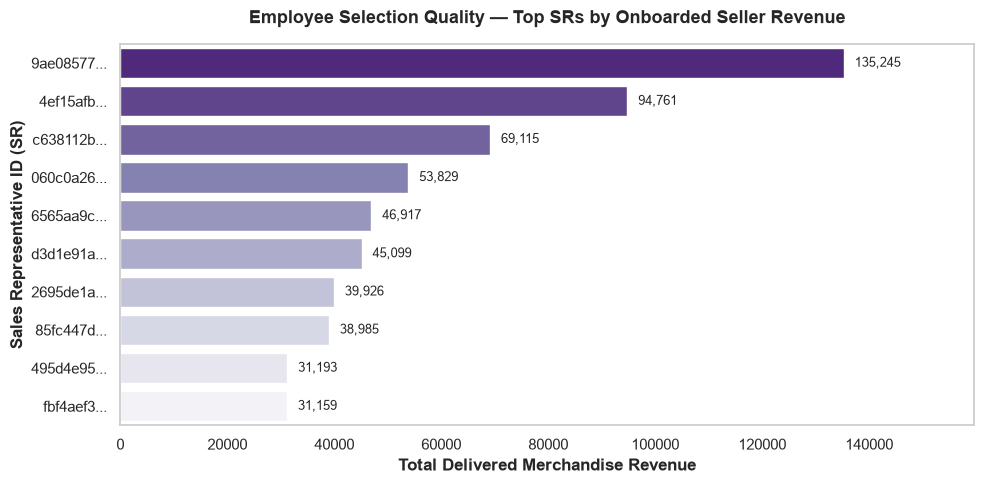

In [44]:
seller_revenue=seller_summary_delivered[["seller_id","total_revenue"]].rename(columns={"total_revenue":"total_seller_revenue"})
sr_performance=closed.merge(seller_revenue,on="seller_id",how="left").fillna({"total_seller_revenue":0})
top_srs=(sr_performance.groupby("sr_id")["total_seller_revenue"].sum().reset_index().sort_values(by="total_seller_revenue",ascending=False).head(10))
top_srs["sr_short"]=top_srs["sr_id"].apply(lambda x:str(x)[:8]+"...")
plt.figure(figsize=(10,5))
sns.set_theme(style="whitegrid")
ax=sns.barplot(data=top_srs,x="total_seller_revenue",y="sr_short",palette="Purples_r")
for p in ax.patches:
    width=p.get_width()
    ax.annotate(f" {width:,.0f}",(width,p.get_y()+p.get_height()/2.0),ha="left",va="center",fontsize=9,xytext=(5,0),textcoords="offset points")
plt.title("Employee Selection Quality — Top SRs by Onboarded Seller Revenue",fontsize=13,fontweight="bold",pad=15)
plt.xlabel("Total Delivered Merchandise Revenue",fontweight="bold")
plt.ylabel("Sales Representative ID (SR)",fontweight="bold")
plt.xlim(0,top_srs["total_seller_revenue"].max()*1.18)
plt.tight_layout()
plt.grid(False)
plt.show()


# Q4

C:\Users\mujta\AppData\Local\Temp\ipykernel_30012\2181843861.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_sellers, x="total_revenue", y="seller_label",  palette="Blues_r",ax=ax,)


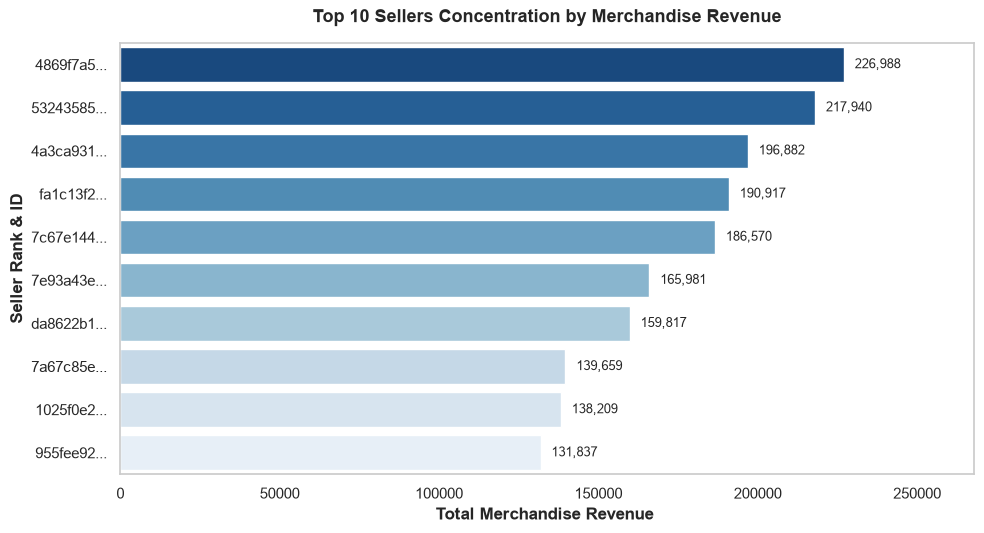

In [45]:
top_10_sellers = (seller_summary.sort_values(by="total_revenue", ascending=False).head(10).copy())

top_10_sellers["seller_label"] = [f"{sid[:8]}..." for i, sid in enumerate(top_10_sellers["seller_id"])]

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.set_theme(style="whitegrid")

sns.barplot(data=top_10_sellers, x="total_revenue", y="seller_label",  palette="Blues_r",ax=ax,)


for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f" {width:,.0f}",
        (width, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        fontsize=9,
        xytext=(5, 0),
        textcoords="offset points",)

ax.set_title("Top 10 Sellers Concentration by Merchandise Revenue", fontsize=13,fontweight="bold",pad=15,)
ax.set_xlabel("Total Merchandise Revenue ", fontweight="bold")
ax.set_ylabel("Seller Rank & ID", fontweight="bold")
ax.set_xlim(0, top_10_sellers["total_revenue"].max() * 1.18)
plt.grid(False)
fig.tight_layout()
plt.show()

# Q5

C:\Users\mujta\AppData\Local\Temp\ipykernel_30012\3609899514.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=top_red_flags,x="late_delivery_rate_%",y="seller_short",palette="Reds_r")


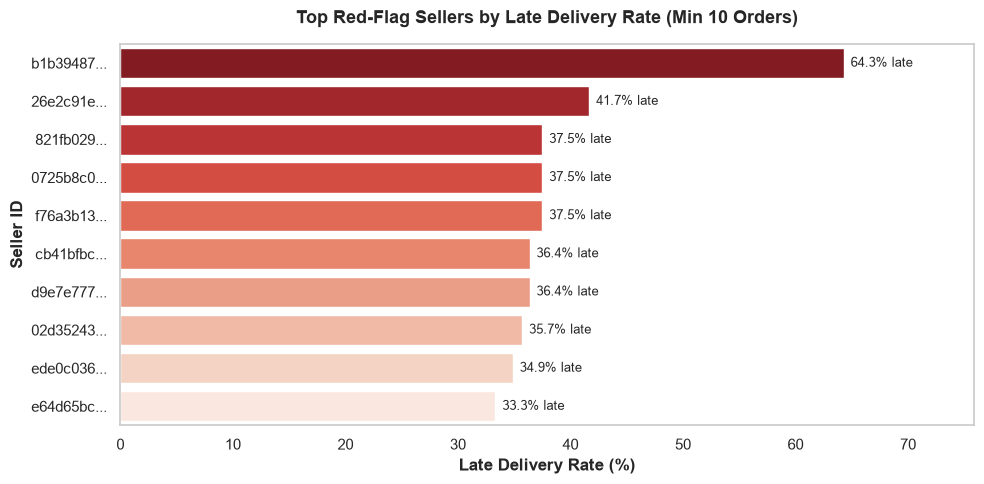

In [46]:
seller_flags_data=seller_order_level_delivered.copy()
seller_flags_data["is_late"]=seller_flags_data["order_delivered_customer_date"]>seller_flags_data["order_estimated_delivery_date"]
seller_flags=(seller_flags_data.groupby("seller_id").agg(total_orders=("order_id","nunique"),avg_review_score=("review_score","mean"),late_orders=("is_late","sum")).reset_index())
seller_flags["late_delivery_rate_%"]=(seller_flags["late_orders"]/seller_flags["total_orders"])*100
red_flag_sellers=seller_flags[(seller_flags["total_orders"]>=10)&((seller_flags["avg_review_score"]<3.0)|(seller_flags["late_delivery_rate_%"]>20.0))].sort_values(by="late_delivery_rate_%",ascending=False)
top_red_flags=red_flag_sellers.head(10).copy()
top_red_flags["seller_short"]=top_red_flags["seller_id"].apply(lambda x:str(x)[:8]+"...")
plt.figure(figsize=(10,5))
sns.set_theme(style="whitegrid")
ax=sns.barplot(data=top_red_flags,x="late_delivery_rate_%",y="seller_short",palette="Reds_r")
for p in ax.patches:
    width=p.get_width()
    ax.annotate(f"{width:.1f}% late",(width,p.get_y()+p.get_height()/2.0),ha="left",va="center",fontsize=9,xytext=(5,0),textcoords="offset points")
plt.title("Top Red-Flag Sellers by Late Delivery Rate (Min 10 Orders)",fontsize=13,fontweight="bold",pad=15)
plt.xlabel("Late Delivery Rate (%)",fontweight="bold")
plt.ylabel("Seller ID",fontweight="bold")
plt.xlim(0,top_red_flags["late_delivery_rate_%"].max()*1.18)
plt.tight_layout()
plt.grid(False)
plt.show()


# Q6

C:\Users\mujta\AppData\Local\Temp\ipykernel_30012\619477572.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_summary, x="business_type", y="total_orders", palette="Set2", ax=ax1)
C:\Users\mujta\AppData\Local\Temp\ipykernel_30012\619477572.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_summary, x="business_type", y="avg_order_value", palette="Set2", ax=ax2,)


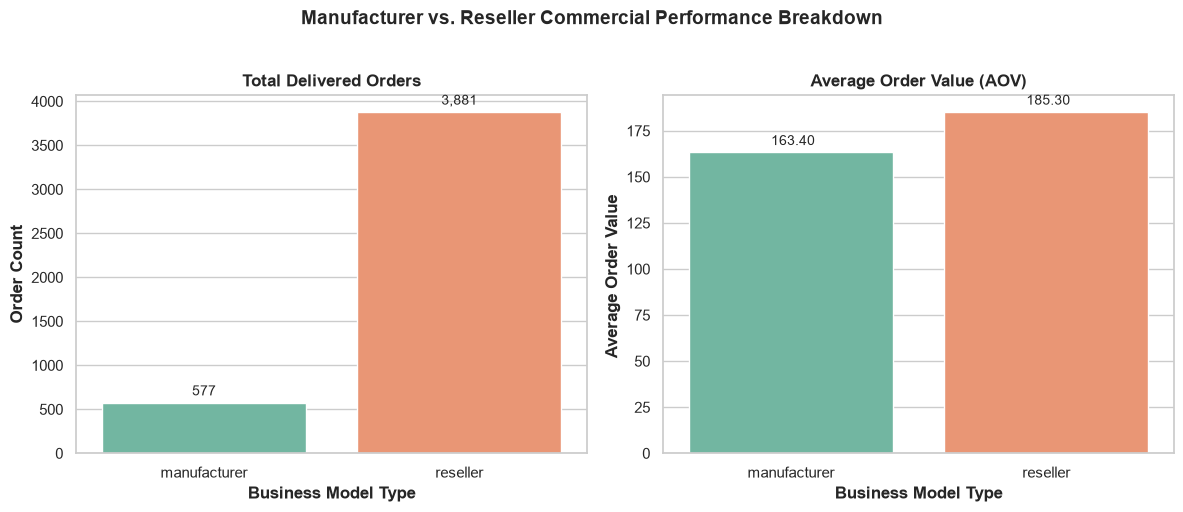

In [47]:
biz_summary = closed.merge(seller_summary, on="seller_id", how="inner")
type_summary = (
    biz_summary.groupby("business_type").agg(
        seller_count=("seller_id", "nunique"),
        total_orders=("total_orders", "sum"),
        total_revenue=("total_revenue", "sum"),
        avg_order_value=("avg_order_value", "mean"),).reset_index())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=type_summary, x="business_type", y="total_orders", palette="Set2", ax=ax1)
ax1.set_title("Total Delivered Orders", fontweight="bold")
ax1.set_xlabel("Business Model Type", fontweight="bold")
ax1.set_ylabel("Order Count", fontweight="bold")

for p in ax1.patches:
    ax1.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points",)


sns.barplot(data=type_summary, x="business_type", y="avg_order_value", palette="Set2", ax=ax2,)
ax2.set_title("Average Order Value (AOV)", fontweight="bold")
ax2.set_xlabel("Business Model Type", fontweight="bold")
ax2.set_ylabel("Average Order Value ", fontweight="bold")

for p in ax2.patches:
    ax2.annotate(
        f" {p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points",)

plt.suptitle("Manufacturer vs. Reseller Commercial Performance Breakdown",fontsize=14,fontweight="bold",y=1.02,)
fig.tight_layout()
plt.show()

# Part 3 — Analysis Questions 7 to 12
This section continues directly from the same cleaning outputs. The Q10 activity rule is set to **7 days**.


**Q7 — What’s the number of orders for each seller type?**

In [48]:
seller_analysis.shape

(842, 24)

In [49]:
seller_analysis["business_type"].value_counts(dropna=False)

business_type
reseller        587
manufacturer    242
NaN              10
other             3
Name: count, dtype: int64

In [50]:
seller_type_data = seller_analysis[
    (seller_analysis["business_type"] == "manufacturer") |
    (seller_analysis["business_type"] == "reseller")].copy()

In [51]:
seller_type_data["business_type"].value_counts()

business_type
reseller        587
manufacturer    242
Name: count, dtype: int64

In [52]:
orders_by_type = (seller_type_data.groupby("business_type").agg(total_orders=("total_orders", "sum")).reset_index())
orders_by_type

,business_type,total_orders
0,manufacturer,577.0
1,reseller,3881.0


In [53]:
seller_count_by_type = (seller_type_data.groupby("business_type").agg(seller_count=("seller_id", "nunique")).reset_index())
seller_count_by_type

,business_type,seller_count
0,manufacturer,242
1,reseller,587


In [54]:
seller_type_summary = (seller_type_data.groupby("business_type").agg(seller_count=("seller_id", "nunique"),total_orders=("total_orders", "sum")).reset_index())
seller_type_summary

,business_type,seller_count,total_orders
0,manufacturer,242,577.0
1,reseller,587,3881.0


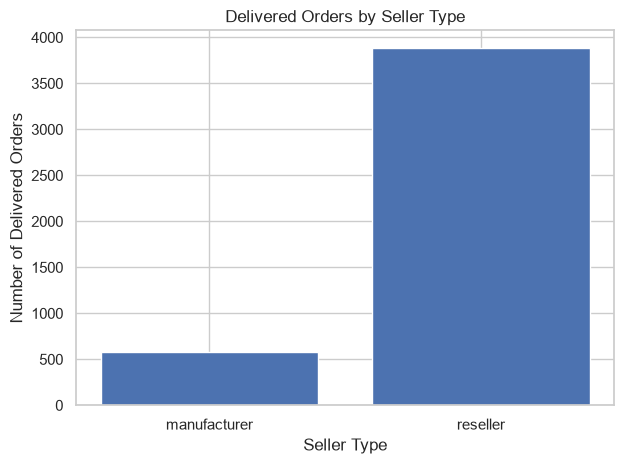

In [55]:
plt.bar(seller_type_summary["business_type"],seller_type_summary["total_orders"])

plt.xlabel("Seller Type")
plt.ylabel("Number of Delivered Orders")
plt.title("Delivered Orders by Seller Type")

plt.tight_layout()
plt.show()

***The resellers made 3,881 orders that were delivered, while only 577 orders made by manufacturers were delivered in the available transaction period.***

***Q8 — Are top sellers successful because of price or customer satisfaction?***

In [56]:
seller_success = seller_summary_delivered.copy()

In [57]:
# Calculate average item price for each seller

seller_price = (seller_order_level_delivered.groupby("seller_id").agg(total_sales=("order_value", "sum"),total_items=("item_count", "sum")).reset_index())
seller_price["average_item_price"] = (seller_price["total_sales"] / seller_price["total_items"])

In [58]:
# Add average item price to seller performance data

seller_success = seller_summary_delivered.merge(seller_price[["seller_id", "average_item_price"]],on="seller_id",how="left")

In [59]:
# Top 10 sellers by delivered sales value

top_10_sellers = (seller_success.sort_values("total_revenue", ascending=False).head(10))
other_sellers = seller_success[~seller_success["seller_id"].isin(top_10_sellers["seller_id"])]

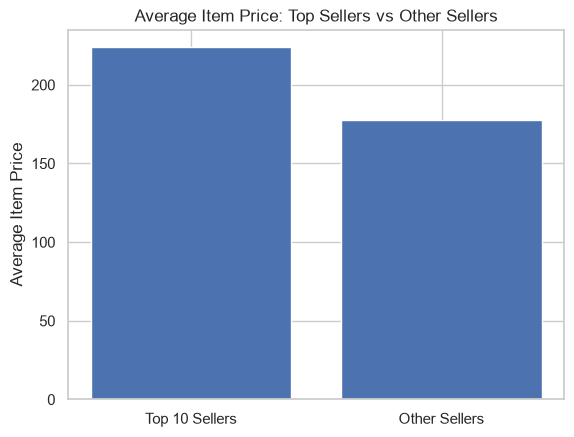

In [60]:
top_price = top_10_sellers["average_item_price"].mean()
other_price = other_sellers["average_item_price"].mean()





plt.bar(
    ["Top 10 Sellers", "Other Sellers"],
    [top_price, other_price])

plt.ylabel("Average Item Price")
plt.title("Average Item Price: Top Sellers vs Other Sellers")

plt.show()

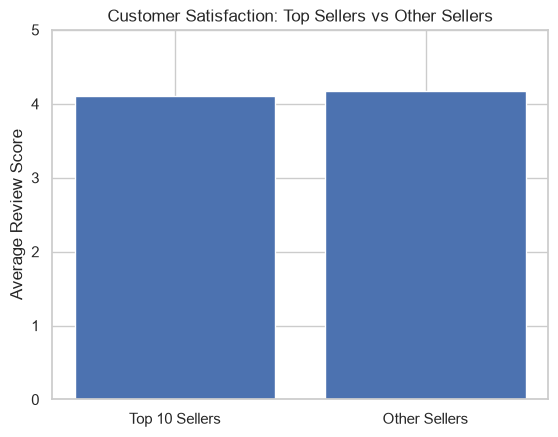

In [61]:
top_review=top_10_sellers["average_review_score"].mean()
other_review=other_sellers["average_review_score"].mean()





plt.bar(["Top 10 Sellers","Other Sellers"],[top_review,other_review])
plt.ylabel("Average Review Score")
plt.title("Customer Satisfaction: Top Sellers vs Other Sellers")
plt.ylim(0,5)
plt.show()

***It seems like top sellers perform better due to higher prices of items instead of higher customer satisfaction. The average price of an item of top sellers is 223.75 compared to 177.50 for other sellers, while the average review score is 4.11 compared to 4.18***

***Q9 — Where are the top sellers located?***

In [62]:
top_10_sellers[["seller_id","seller_city","seller_state","total_revenue"]]

,seller_id,seller_city,seller_state,total_revenue
834,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,226987.93
982,53243585a1d6dc2643021fd1853d8905,lauro de freitas,BA,217940.44
858,4a3ca9315b744ce9f8e9374361493884,ibitinga,SP,196882.12
2903,fa1c13f2614d7b5c4749cbc52fecda94,sumare,SP,190917.14
1480,7c67e1448b00f6e969d365cea6b010ab,itaquaquecetuba,SP,186570.05
1504,7e93a43ef30c4f03f38b393420bc753a,barueri,SP,165981.49
2543,da8622b14eb17ae2831f4ac5b9dab84a,piracicaba,SP,159816.87
1450,7a67c85e85bb2ce8582c35f2203ad736,sao paulo,SP,139658.69
188,1025f0e2d44d7041d6cf58b6550e0bfa,sao paulo,SP,138208.56
1758,955fee9216a65b617aa5c0531780ce60,sao paulo,SP,131836.71


In [63]:
top_seller_states=top_10_sellers["seller_state"].value_counts().reset_index()
top_seller_states.columns=["state","top_seller_count"]
top_seller_states

,state,top_seller_count
0,SP,9
1,BA,1


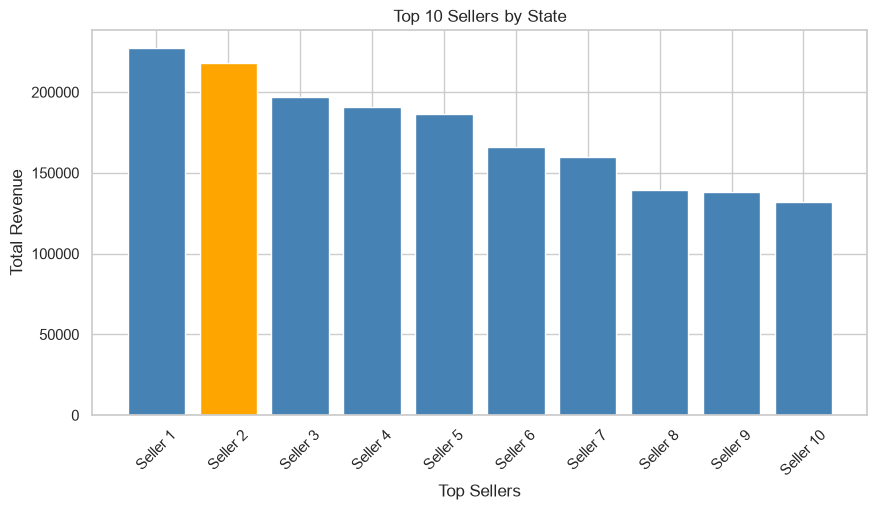

In [64]:
top_10_sellers=top_10_sellers.sort_values("total_revenue",ascending=False).reset_index(drop=True)
top_10_sellers["seller_rank"]=["Seller "+str(i) for i in range(1,11)]
colors=["steelblue" if state=="SP" else "orange" for state in top_10_sellers["seller_state"]]
plt.figure(figsize=(10,5))
plt.bar(top_10_sellers["seller_rank"],top_10_sellers["total_revenue"],color=colors)
plt.xlabel("Top Sellers")
plt.ylabel("Total Revenue")
plt.title("Top 10 Sellers by State")
plt.xticks(rotation=45)
plt.show()

***Most of the top sellers operate in SP. Out of the top 10 sellers, nine of them are from SP and only one is from BA.***

***Q10 — How many sellers do we have, and are all of them active?***

In [65]:
last_order_date=seller_order_level_all["order_purchase_timestamp"].max()
seller_last_order=seller_order_level_all.groupby("seller_id")["order_purchase_timestamp"].max().reset_index()


In [66]:
seller_activity=sellers[["seller_id"]].merge(seller_last_order,on="seller_id",how="left")
seller_activity["days_since_last_order"]=(last_order_date-seller_activity["order_purchase_timestamp"]).dt.days
seller_activity["active"]=seller_activity["days_since_last_order"]<=7
total_sellers=seller_activity["seller_id"].nunique()
active_sellers=seller_activity["active"].sum()
inactive_sellers=total_sellers-active_sellers


In [67]:
print("Total sellers:",total_sellers)
print("Active sellers:",active_sellers)
print("Inactive sellers:",inactive_sellers)
print("Last order date:",last_order_date)
print(f"Answer: There are {total_sellers:,} sellers in total. Using the 7-day activity definition, {active_sellers:,} are active and {inactive_sellers:,} are inactive.")


Total sellers: 3095
Active sellers: 137
Inactive sellers: 2958
Last order date: 2018-09-03 09:06:57
Answer: There are 3,095 sellers in total. Using the 7-day activity definition, 137 are active and 2,958 are inactive.


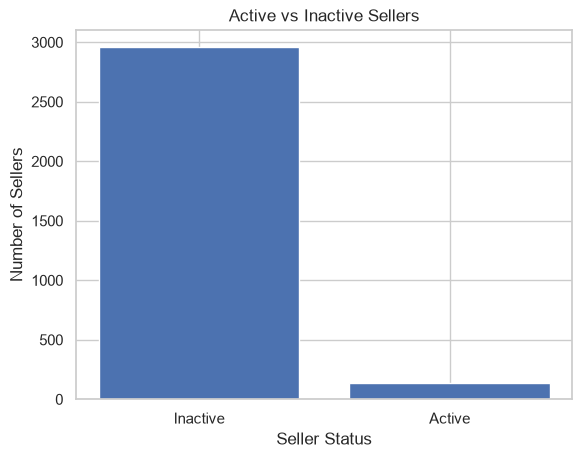

In [68]:
activity_counts=seller_activity["active"].value_counts().reset_index()
activity_counts.columns=["active","seller_count"]
activity_counts["status"]=activity_counts["active"].map({True:"Active",False:"Inactive"})
plt.bar(activity_counts["status"],activity_counts["seller_count"])
plt.xlabel("Seller Status")
plt.ylabel("Number of Sellers")
plt.title("Active vs Inactive Sellers")
plt.show()

***Q10 Answer — There are 3,095 sellers in total. For this project, an active seller is defined as a seller whose most recent recorded order occurred within 7 days of the final order date in the dataset. The exact active and inactive counts are generated by the code above.***


***Q11 — Which states have customers but zero sellers?***

In [69]:
customers_by_state=customers.groupby("customer_state")["customer_unique_id"].nunique().reset_index()
customers_by_state.columns=["state","customer_count"]


In [70]:
sellers_by_state=sellers.groupby("seller_state")["seller_id"].nunique().reset_index()
sellers_by_state.columns=["state","seller_count"]


In [71]:
state_coverage=customers_by_state.merge(sellers_by_state,on="state",how="left")


In [72]:
state_coverage["seller_count"]=state_coverage["seller_count"].fillna(0)
states_no_sellers=state_coverage[state_coverage["seller_count"]==0]
states_no_sellers

,state,customer_count,seller_count
1,AL,401,0.0
3,AP,67,0.0
21,RR,45,0.0
26,TO,273,0.0


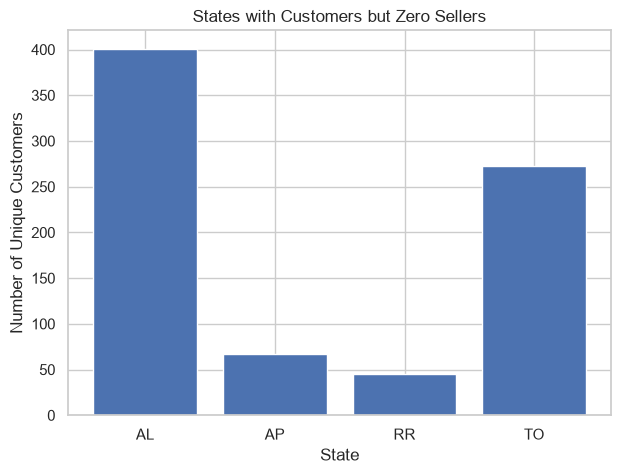

In [73]:
plt.figure(figsize=(7,5))
plt.bar(states_no_sellers["state"],states_no_sellers["customer_count"])
plt.xlabel("State")
plt.ylabel("Number of Unique Customers")
plt.title("States with Customers but Zero Sellers")
plt.show()

***There are four states where there are some customers, but no sellers: AL, AP, RR, and TO. The state AL has the highest number of customers with 401 customers, then TO with 273, AP with 67, and RR with 45 customers.***

ٍٍ***Q12 — Do we have a good seller-to-customer ratio?***

In [74]:
state_coverage["sellers_per_1000_customers"]=(state_coverage["seller_count"]/state_coverage["customer_count"])*1000
state_ratio=state_coverage.sort_values("sellers_per_1000_customers",ascending=True)
state_ratio[["state","customer_count","seller_count","sellers_per_1000_customers"]]

,state,customer_count,seller_count,sellers_per_1000_customers
1,AL,401,0.0,0.000000
3,AP,67,0.0,0.000000
26,TO,273,0.0,0.000000
21,RR,45,0.0,0.000000
13,PA,949,1.0,1.053741
9,MA,726,1.0,1.377410
16,PI,482,1.0,2.074689
12,MT,876,4.0,4.566210
15,PE,1609,9.0,5.593536
4,BA,3277,19.0,5.797986


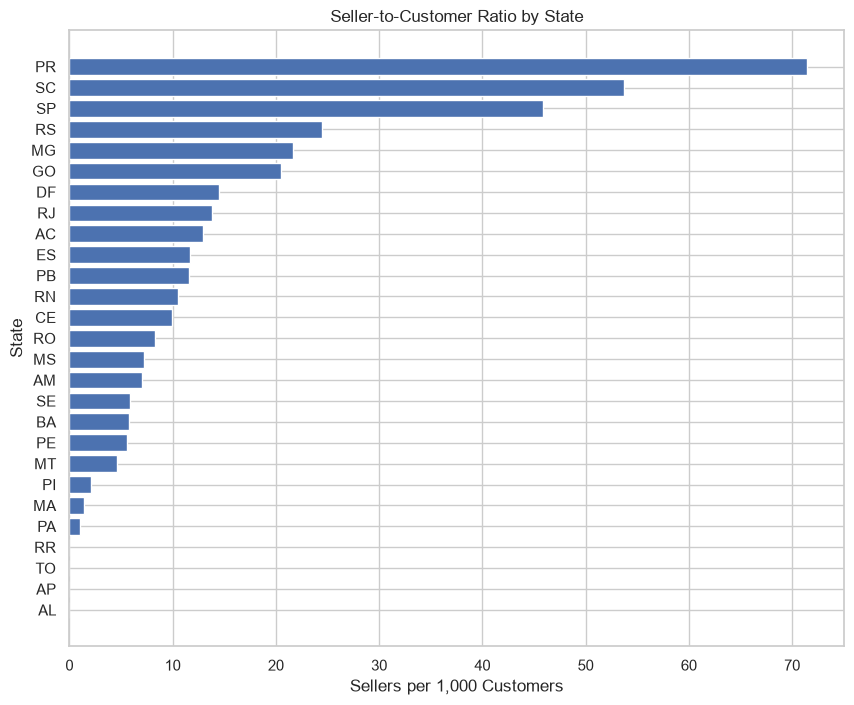

In [75]:
plt.figure(figsize=(10,8))
plt.barh(state_ratio["state"],state_ratio["sellers_per_1000_customers"])
plt.xlabel("Sellers per 1,000 Customers")
plt.ylabel("State")
plt.title("Seller-to-Customer Ratio by State")
plt.show()

***The ratio between seller and customer is uneven in different states. PR has the highest seller coverage of approximately 71 sellers per 1,000 customers, followed by SC and SP. AL, AP, RR, and TO states have customers, but no sellers.***

# Part 4 — Additional Analysis Questions
This section uses the same cleaned DataFrames from Part 1. No separate cleaned CSV files are required.

**Important definition:** In this section, `active_seller` is used as an **activation** flag for signed sellers (has recorded delivered-order performance). This is different from Q10, where 'active' means the seller's last recorded order was within 7 days of the end of the dataset.


In [76]:
seller_order_level=seller_order_level_all.copy()
seller_analysis["revenue_per_order"]=seller_analysis["total_revenue"]/seller_analysis["total_orders"]
first_sale=seller_order_level_all.groupby("seller_id")["order_purchase_timestamp"].min().reset_index(name="first_sale_date")
seller_analysis=seller_analysis.merge(first_sale,on="seller_id",how="left")
seller_analysis["days_to_first_sale"]=(seller_analysis["first_sale_date"]-seller_analysis["won_date"]).dt.days


# Olist Seller Evaluation & Channel Analysis
## Assigned Analysis Questions
Which employees are hiring the best vs. worst sellers?

Provide specific, data-driven recommendations.

Explore population density and demographics in states with no sellers.

Compare average revenue per order between manufacturers and resellers.

Assess whether seller location affects delivery time.

Which lead channel (e.g., Organic Search, Paid Search, Social) brings sellers with the highest retention and order volume?

What percentage of signed sellers never list a product or make their first sale within 30/60 days of onboarding?

## 1. Which employees are hiring the best vs. worst sellers?

In [77]:
# Activation flag for signed sellers in this section:
# True = seller has recorded delivered-order performance
seller_analysis["active_seller"]=seller_analysis["total_orders"].notna()
seller_analysis["active_seller"].value_counts()


active_seller
False    466
True     376
Name: count, dtype: int64

In [78]:
#SR performance table
sr_summary = seller_analysis.groupby("sr_id").agg(
    sellers_hired=("seller_id", "count"),
    active_sellers=("active_seller", "sum"),
    average_orders=("total_orders", "mean"),
    average_revenue=("total_revenue", "mean"),
    average_review=("average_review_score", "mean")
).reset_index()

In [79]:
#activation rate
sr_summary["active_rate"] = (sr_summary["active_sellers"] /sr_summary["sellers_hired"]) * 100

In [80]:
sr_summary

,sr_id,sellers_hired,active_sellers,average_orders,average_revenue,average_review,active_rate
0,060c0a26f19f4d66b42e0d8796688490,32,14,25.642857,3844.909286,4.499981,43.750000
1,068066e24f0c643eb1d089c7dd20cd73,27,6,16.666667,1132.110000,4.318750,22.222222
2,0a0fb2b07d841f84fb6714e35c723075,1,0,NaN,NaN,NaN,0.000000
3,2695de1affa7750089c0455f8ce27021,59,20,9.450000,1996.276500,4.322336,33.898305
4,34d40cdaf94010a1d05b0d6212f9e909,10,2,14.500000,2386.220000,4.483333,20.000000
5,495d4e95a8cf8bbf8b432b612a2aa328,63,29,10.655172,1075.623103,4.291049,46.031746
6,4b339f9567d060bcea4f5136b9f5949e,9,1,2.000000,102.050000,5.000000,11.111111
7,4ef15afb4b2723d8f3d81e51ec7afefe,133,74,10.162162,1280.549459,4.355776,55.639098
8,56bf83c4bb35763a51c2baab501b4c67,24,11,11.090909,1437.600000,4.704541,45.833333
9,6565aa9ce3178a5caf6171827af3a9ba,74,35,9.314286,1340.494571,4.294537,47.297297


In [81]:
#filter out very small employee samples
sr_summary_fair = sr_summary[sr_summary["sellers_hired"] >= 10].copy()

print("SRs included:", len(sr_summary_fair))

SRs included: 16


In [82]:
#strongest activation rates
sr_summary_fair.sort_values("active_rate",ascending=False)

,sr_id,sellers_hired,active_sellers,average_orders,average_revenue,average_review,active_rate
7,4ef15afb4b2723d8f3d81e51ec7afefe,133,74,10.162162,1280.549459,4.355776,55.639098
21,fbf4aef3f6915dc0c3c97d6812522f6a,59,30,6.466667,1038.645667,4.283479,50.847458
11,85fc447d336637ba1df43e793199fbc8,64,32,5.656250,1218.279063,4.126631,50.000000
16,a8387c01a09e99ce014107505b92388c,26,13,5.692308,464.442308,4.461538,50.000000
15,9e4d1098a3b0f5da39b0bc48f9876645,24,12,17.750000,1549.477500,4.077531,50.000000
19,d3d1e91a157ea7f90548eef82f1955e3,82,41,10.829268,1099.976829,4.441168,50.000000
9,6565aa9ce3178a5caf6171827af3a9ba,74,35,9.314286,1340.494571,4.294537,47.297297
5,495d4e95a8cf8bbf8b432b612a2aa328,63,29,10.655172,1075.623103,4.291049,46.031746
8,56bf83c4bb35763a51c2baab501b4c67,24,11,11.090909,1437.600000,4.704541,45.833333
0,060c0a26f19f4d66b42e0d8796688490,32,14,25.642857,3844.909286,4.499981,43.750000


In [83]:
#strongest average order volume
sr_summary_fair.sort_values("average_orders",ascending=False)

,sr_id,sellers_hired,active_sellers,average_orders,average_revenue,average_review,active_rate
13,9ae085775a198122c5586fa830ff7f2b,51,22,35.090909,6147.481364,4.389495,43.137255
0,060c0a26f19f4d66b42e0d8796688490,32,14,25.642857,3844.909286,4.499981,43.750000
15,9e4d1098a3b0f5da39b0bc48f9876645,24,12,17.750000,1549.477500,4.077531,50.000000
1,068066e24f0c643eb1d089c7dd20cd73,27,6,16.666667,1132.110000,4.318750,22.222222
18,c638112b43f1d1b86dcabb0da720c901,36,15,16.533333,4607.670000,4.400502,41.666667
4,34d40cdaf94010a1d05b0d6212f9e909,10,2,14.500000,2386.220000,4.483333,20.000000
8,56bf83c4bb35763a51c2baab501b4c67,24,11,11.090909,1437.600000,4.704541,45.833333
19,d3d1e91a157ea7f90548eef82f1955e3,82,41,10.829268,1099.976829,4.441168,50.000000
5,495d4e95a8cf8bbf8b432b612a2aa328,63,29,10.655172,1075.623103,4.291049,46.031746
7,4ef15afb4b2723d8f3d81e51ec7afefe,133,74,10.162162,1280.549459,4.355776,55.639098


In [84]:
#strongest average revenue
sr_summary_fair.sort_values("average_revenue",ascending=False)

,sr_id,sellers_hired,active_sellers,average_orders,average_revenue,average_review,active_rate
13,9ae085775a198122c5586fa830ff7f2b,51,22,35.090909,6147.481364,4.389495,43.137255
18,c638112b43f1d1b86dcabb0da720c901,36,15,16.533333,4607.670000,4.400502,41.666667
0,060c0a26f19f4d66b42e0d8796688490,32,14,25.642857,3844.909286,4.499981,43.750000
4,34d40cdaf94010a1d05b0d6212f9e909,10,2,14.500000,2386.220000,4.483333,20.000000
3,2695de1affa7750089c0455f8ce27021,59,20,9.450000,1996.276500,4.322336,33.898305
15,9e4d1098a3b0f5da39b0bc48f9876645,24,12,17.750000,1549.477500,4.077531,50.000000
20,de63de0d10a6012430098db33c679b0b,53,18,8.222222,1470.415556,4.358938,33.962264
8,56bf83c4bb35763a51c2baab501b4c67,24,11,11.090909,1437.600000,4.704541,45.833333
9,6565aa9ce3178a5caf6171827af3a9ba,74,35,9.314286,1340.494571,4.294537,47.297297
7,4ef15afb4b2723d8f3d81e51ec7afefe,133,74,10.162162,1280.549459,4.355776,55.639098


In [85]:
#separate analysis copy
sr_analysis_data = seller_analysis.copy()

In [86]:
#treat sellers with no recorded transactions as zero for this specific employee-performance calculation
sr_analysis_data["total_orders_for_employee"] = (sr_analysis_data["total_orders"].fillna(0))

sr_analysis_data["total_revenue_for_employee"] = (sr_analysis_data["total_revenue"].fillna(0))

In [87]:
#overall SR table
sr_overall = sr_analysis_data.groupby("sr_id").agg(
    sellers_hired=("seller_id", "count"),
    active_sellers=("active_seller", "sum"),
    total_orders=("total_orders_for_employee", "sum"),
    total_revenue=("total_revenue_for_employee", "sum"),
    average_review=("average_review_score", "mean")
).reset_index()

In [88]:
sr_overall["active_rate"] = (sr_overall["active_sellers"] /sr_overall["sellers_hired"]) * 100

In [89]:
#productivity per seller hired
sr_overall["orders_per_hired_seller"] = (sr_overall["total_orders"] /sr_overall["sellers_hired"])

sr_overall["revenue_per_hired_seller"] = (sr_overall["total_revenue"] /sr_overall["sellers_hired"])

In [90]:
sr_overall_fair = sr_overall[sr_overall["sellers_hired"] >= 10].copy()

In [91]:
sr_overall_fair.sort_values("revenue_per_hired_seller",ascending=False)

,sr_id,sellers_hired,active_sellers,total_orders,total_revenue,average_review,active_rate,orders_per_hired_seller,revenue_per_hired_seller
13,9ae085775a198122c5586fa830ff7f2b,51,22,772.0,135244.59,4.389495,43.137255,15.137255,2651.854706
18,c638112b43f1d1b86dcabb0da720c901,36,15,248.0,69115.05,4.400502,41.666667,6.888889,1919.862500
0,060c0a26f19f4d66b42e0d8796688490,32,14,359.0,53828.73,4.499981,43.750000,11.218750,1682.147812
15,9e4d1098a3b0f5da39b0bc48f9876645,24,12,213.0,18593.73,4.077531,50.000000,8.875000,774.738750
7,4ef15afb4b2723d8f3d81e51ec7afefe,133,74,752.0,94760.66,4.355776,55.639098,5.654135,712.486165
3,2695de1affa7750089c0455f8ce27021,59,20,189.0,39925.53,4.322336,33.898305,3.203390,676.703898
8,56bf83c4bb35763a51c2baab501b4c67,24,11,122.0,15813.60,4.704541,45.833333,5.083333,658.900000
9,6565aa9ce3178a5caf6171827af3a9ba,74,35,326.0,46917.31,4.294537,47.297297,4.405405,634.017703
11,85fc447d336637ba1df43e793199fbc8,64,32,181.0,38984.93,4.126631,50.000000,2.828125,609.139531
19,d3d1e91a157ea7f90548eef82f1955e3,82,41,444.0,45099.05,4.441168,50.000000,5.414634,549.988415


In [92]:
sr_overall_fair.sort_values("orders_per_hired_seller",ascending=False)

,sr_id,sellers_hired,active_sellers,total_orders,total_revenue,average_review,active_rate,orders_per_hired_seller,revenue_per_hired_seller
13,9ae085775a198122c5586fa830ff7f2b,51,22,772.0,135244.59,4.389495,43.137255,15.137255,2651.854706
0,060c0a26f19f4d66b42e0d8796688490,32,14,359.0,53828.73,4.499981,43.750000,11.218750,1682.147812
15,9e4d1098a3b0f5da39b0bc48f9876645,24,12,213.0,18593.73,4.077531,50.000000,8.875000,774.738750
18,c638112b43f1d1b86dcabb0da720c901,36,15,248.0,69115.05,4.400502,41.666667,6.888889,1919.862500
7,4ef15afb4b2723d8f3d81e51ec7afefe,133,74,752.0,94760.66,4.355776,55.639098,5.654135,712.486165
19,d3d1e91a157ea7f90548eef82f1955e3,82,41,444.0,45099.05,4.441168,50.000000,5.414634,549.988415
8,56bf83c4bb35763a51c2baab501b4c67,24,11,122.0,15813.60,4.704541,45.833333,5.083333,658.900000
5,495d4e95a8cf8bbf8b432b612a2aa328,63,29,309.0,31193.07,4.291049,46.031746,4.904762,495.128095
9,6565aa9ce3178a5caf6171827af3a9ba,74,35,326.0,46917.31,4.294537,47.297297,4.405405,634.017703
1,068066e24f0c643eb1d089c7dd20cd73,27,6,100.0,6792.66,4.318750,22.222222,3.703704,251.580000


In [93]:
#SDR side
sdr_overall = sr_analysis_data.groupby("sdr_id").agg(
    sellers_handled=("seller_id", "count"),
    active_sellers=("active_seller", "sum"),
    total_orders=("total_orders_for_employee", "sum"),
    total_revenue=("total_revenue_for_employee", "sum"),
    average_review=("average_review_score", "mean")
).reset_index()

In [94]:
sdr_overall["active_rate"] = (sdr_overall["active_sellers"] /sdr_overall["sellers_handled"]) * 100

In [95]:
sdr_overall["orders_per_seller"] = (sdr_overall["total_orders"] /sdr_overall["sellers_handled"])
sdr_overall["revenue_per_seller"] = (sdr_overall["total_revenue"] /sdr_overall["sellers_handled"])

In [96]:
sdr_overall_fair = sdr_overall[sdr_overall["sellers_handled"] >= 10].copy()

In [97]:
#Filter small samples
sdr_overall_fair = sdr_overall[sdr_overall["sellers_handled"] >= 10].copy()

In [98]:
sdr_overall_fair.sort_values("active_rate",ascending=False)

,sdr_id,sellers_handled,active_sellers,total_orders,total_revenue,average_review,active_rate,orders_per_seller,revenue_per_seller
25,b90f87164b5f8c2cfa5c8572834dbe3f,25,15,185.0,35507.06,4.402704,60.000000,7.400000,1420.282400
22,a8387c01a09e99ce014107505b92388c,59,34,271.0,55018.33,4.187656,57.627119,4.593220,932.514068
21,9e4d1098a3b0f5da39b0bc48f9876645,55,30,503.0,63021.67,4.317174,54.545455,9.145455,1145.848545
0,068066e24f0c643eb1d089c7dd20cd73,81,43,409.0,65035.95,4.398854,53.086420,5.049383,802.912963
13,4b339f9567d060bcea4f5136b9f5949e,140,69,606.0,65956.70,4.295861,49.285714,4.328571,471.119286
2,09285259593c61296eef10c734121d5b,42,20,144.0,10049.13,4.328119,47.619048,3.428571,239.265000
20,9d12ef1a7eca3ec58c545c678af7869c,66,31,413.0,47631.59,4.294536,46.969697,6.257576,721.690758
26,de63de0d10a6012430098db33c679b0b,53,24,273.0,34183.75,4.493431,45.283019,5.150943,644.976415
31,fdb16d3cbbeb5798f2f66c4096be026d,34,15,246.0,27762.47,4.264897,44.117647,7.235294,816.543235
11,370c9f455f93a9a96cbe9bea48e70033,51,21,249.0,32148.79,4.396452,41.176471,4.882353,630.368431


In [99]:
sdr_overall_fair.sort_values("orders_per_seller",ascending=False)

,sdr_id,sellers_handled,active_sellers,total_orders,total_revenue,average_review,active_rate,orders_per_seller,revenue_per_seller
14,56bf83c4bb35763a51c2baab501b4c67,74,30,776.0,181198.67,4.473802,40.540541,10.486486,2448.630676
21,9e4d1098a3b0f5da39b0bc48f9876645,55,30,503.0,63021.67,4.317174,54.545455,9.145455,1145.848545
25,b90f87164b5f8c2cfa5c8572834dbe3f,25,15,185.0,35507.06,4.402704,60.000000,7.400000,1420.282400
31,fdb16d3cbbeb5798f2f66c4096be026d,34,15,246.0,27762.47,4.264897,44.117647,7.235294,816.543235
20,9d12ef1a7eca3ec58c545c678af7869c,66,31,413.0,47631.59,4.294536,46.969697,6.257576,721.690758
26,de63de0d10a6012430098db33c679b0b,53,24,273.0,34183.75,4.493431,45.283019,5.150943,644.976415
0,068066e24f0c643eb1d089c7dd20cd73,81,43,409.0,65035.95,4.398854,53.086420,5.049383,802.912963
11,370c9f455f93a9a96cbe9bea48e70033,51,21,249.0,32148.79,4.396452,41.176471,4.882353,630.368431
3,0a0fb2b07d841f84fb6714e35c723075,25,9,121.0,15167.59,4.611607,36.000000,4.840000,606.703600
22,a8387c01a09e99ce014107505b92388c,59,34,271.0,55018.33,4.187656,57.627119,4.593220,932.514068


In [100]:
sdr_overall_fair.sort_values("revenue_per_seller",ascending=False)

,sdr_id,sellers_handled,active_sellers,total_orders,total_revenue,average_review,active_rate,orders_per_seller,revenue_per_seller
14,56bf83c4bb35763a51c2baab501b4c67,74,30,776.0,181198.67,4.473802,40.540541,10.486486,2448.630676
25,b90f87164b5f8c2cfa5c8572834dbe3f,25,15,185.0,35507.06,4.402704,60.000000,7.400000,1420.282400
21,9e4d1098a3b0f5da39b0bc48f9876645,55,30,503.0,63021.67,4.317174,54.545455,9.145455,1145.848545
22,a8387c01a09e99ce014107505b92388c,59,34,271.0,55018.33,4.187656,57.627119,4.593220,932.514068
31,fdb16d3cbbeb5798f2f66c4096be026d,34,15,246.0,27762.47,4.264897,44.117647,7.235294,816.543235
0,068066e24f0c643eb1d089c7dd20cd73,81,43,409.0,65035.95,4.398854,53.086420,5.049383,802.912963
20,9d12ef1a7eca3ec58c545c678af7869c,66,31,413.0,47631.59,4.294536,46.969697,6.257576,721.690758
26,de63de0d10a6012430098db33c679b0b,53,24,273.0,34183.75,4.493431,45.283019,5.150943,644.976415
11,370c9f455f93a9a96cbe9bea48e70033,51,21,249.0,32148.79,4.396452,41.176471,4.882353,630.368431
3,0a0fb2b07d841f84fb6714e35c723075,25,9,121.0,15167.59,4.611607,36.000000,4.840000,606.703600


## 2. Compare average revenue per order between manufacturers and resellers

In [101]:
seller_analysis["business_type"].value_counts(dropna=False)

business_type
reseller        587
manufacturer    242
NaN              10
other             3
Name: count, dtype: int64

In [102]:
#manufacturers and resellers with transactions
business_type_active = seller_analysis[(seller_analysis["business_type"].isin(["manufacturer", "reseller"]))&(seller_analysis["revenue_per_order"].notna())
].copy()

In [103]:
business_type_active["business_type"].value_counts()

business_type
reseller        284
manufacturer     89
Name: count, dtype: int64

In [104]:
#average revenue per order
business_type_comparison = business_type_active.groupby("business_type")["revenue_per_order"].mean()
business_type_comparison

business_type
manufacturer    163.398642
reseller        185.303022
Name: revenue_per_order, dtype: float64

In [105]:
#median
business_type_active.groupby("business_type")["revenue_per_order"].median()

business_type
manufacturer    113.015
reseller         92.425
Name: revenue_per_order, dtype: float64

In [106]:
#Adding order volume and seller count for context
business_type_summary = business_type_active.groupby("business_type").agg(
    sellers=("seller_id", "count"),
    average_orders=("total_orders", "mean"),
    average_revenue_per_order=("revenue_per_order", "mean"),
    median_revenue_per_order=("revenue_per_order", "median"),
    average_review=("average_review_score", "mean")
).reset_index()

business_type_summary

,business_type,sellers,average_orders,average_revenue_per_order,median_revenue_per_order,average_review
0,manufacturer,89,6.483146,163.398642,113.015,4.334211
1,reseller,284,13.665493,185.303022,92.425,4.345139


## 3. Which lead channel brings sellers with the highest retention and order volume?

In [107]:
#Build channel summary
channel_summary = seller_analysis.groupby("origin").agg(
    signed_sellers=("seller_id", "count"),
    active_sellers=("active_seller", "sum"),
    average_orders=("total_orders", "mean"),
    average_revenue=("total_revenue", "mean"),
    average_review=("average_review_score", "mean")
).reset_index()

In [108]:
channel_summary["active_rate"] = (channel_summary["active_sellers"] /channel_summary["signed_sellers"]) * 100

In [109]:
channel_summary

,origin,signed_sellers,active_sellers,average_orders,average_revenue,average_review,active_rate
0,direct_traffic,56,31,6.161290,704.932258,4.319229,55.357143
1,display,6,2,3.500000,461.500000,4.250000,33.333333
2,email,15,6,3.666667,1414.165000,4.622222,40.000000
3,organic_search,271,111,10.729730,1842.430541,4.353061,40.959410
4,other,4,2,43.000000,3388.375000,4.131250,50.000000
5,other_publicities,3,0,NaN,NaN,NaN,0.000000
6,paid_search,195,100,12.340000,1514.441500,4.319120,51.282051
7,referral,24,9,7.444444,1842.027778,4.468376,37.500000
8,social,75,31,12.548387,1399.812903,4.403783,41.333333
9,unknown,179,80,15.812500,2620.642125,4.330683,44.692737


In [110]:
#Rank by active rate
channel_summary.sort_values("active_rate",ascending=False)

,origin,signed_sellers,active_sellers,average_orders,average_revenue,average_review,active_rate
0,direct_traffic,56,31,6.161290,704.932258,4.319229,55.357143
6,paid_search,195,100,12.340000,1514.441500,4.319120,51.282051
4,other,4,2,43.000000,3388.375000,4.131250,50.000000
9,unknown,179,80,15.812500,2620.642125,4.330683,44.692737
8,social,75,31,12.548387,1399.812903,4.403783,41.333333
3,organic_search,271,111,10.729730,1842.430541,4.353061,40.959410
2,email,15,6,3.666667,1414.165000,4.622222,40.000000
7,referral,24,9,7.444444,1842.027778,4.468376,37.500000
1,display,6,2,3.500000,461.500000,4.250000,33.333333
5,other_publicities,3,0,NaN,NaN,NaN,0.000000


In [111]:
#Rank by order volume
channel_summary.sort_values("average_orders",ascending=False)

,origin,signed_sellers,active_sellers,average_orders,average_revenue,average_review,active_rate
4,other,4,2,43.000000,3388.375000,4.131250,50.000000
9,unknown,179,80,15.812500,2620.642125,4.330683,44.692737
8,social,75,31,12.548387,1399.812903,4.403783,41.333333
6,paid_search,195,100,12.340000,1514.441500,4.319120,51.282051
3,organic_search,271,111,10.729730,1842.430541,4.353061,40.959410
7,referral,24,9,7.444444,1842.027778,4.468376,37.500000
0,direct_traffic,56,31,6.161290,704.932258,4.319229,55.357143
2,email,15,6,3.666667,1414.165000,4.622222,40.000000
1,display,6,2,3.500000,461.500000,4.250000,33.333333
5,other_publicities,3,0,NaN,NaN,NaN,0.000000


In [112]:
channel_summary[["origin", "signed_sellers", "active_sellers", "active_rate", "average_orders"]]

,origin,signed_sellers,active_sellers,active_rate,average_orders
0,direct_traffic,56,31,55.357143,6.161290
1,display,6,2,33.333333,3.500000
2,email,15,6,40.000000,3.666667
3,organic_search,271,111,40.959410,10.729730
4,other,4,2,50.000000,43.000000
5,other_publicities,3,0,0.000000,NaN
6,paid_search,195,100,51.282051,12.340000
7,referral,24,9,37.500000,7.444444
8,social,75,31,41.333333,12.548387
9,unknown,179,80,44.692737,15.812500


## 4. What percentage of signed sellers never list a product or make their first sale within 30/60 days of onboarding?

In [113]:
print("Total signed sellers:", len(seller_analysis))
print("Sellers with a recorded first sale:",seller_analysis["first_sale_date"].notna().sum())
print("Sellers with no recorded first sale:",seller_analysis["first_sale_date"].isna().sum())

Total signed sellers: 842
Sellers with a recorded first sale: 380
Sellers with no recorded first sale: 462


In [114]:
not_sold_30 = (seller_analysis["first_sale_date"].isna()|(seller_analysis["days_to_first_sale"] > 30))

print("Not sold within 30 days:", not_sold_30.sum())

print("Percentage:",round(not_sold_30.mean() * 100, 2),"%")

Not sold within 30 days: 709
Percentage: 84.2 %


In [115]:
not_sold_60 = (seller_analysis["first_sale_date"].isna()|(seller_analysis["days_to_first_sale"] > 60))
print("Not sold within 60 days:", not_sold_60.sum())

print("Percentage:",round(not_sold_60.mean() * 100, 2),"%")

Not sold within 60 days: 592
Percentage: 70.31 %


In [116]:
sold_30 = (seller_analysis["first_sale_date"].notna()&(seller_analysis["days_to_first_sale"] <= 30))
sold_60 = (seller_analysis["first_sale_date"].notna()&(seller_analysis["days_to_first_sale"] <= 60))

print("Sold within 30 days:", sold_30.sum())
print("Sold within 60 days:", sold_60.sum())

print("Percentage sold within 30 days:",round(sold_30.mean() * 100, 2),"%")
print("Percentage sold within 60 days:",round(sold_60.mean() * 100, 2),"%")

Sold within 30 days: 133
Sold within 60 days: 250
Percentage sold within 30 days: 15.8 %
Percentage sold within 60 days: 29.69 %


## 5. Assess whether seller location affects delivery time

In [117]:
#seller-delivery data
delivery_analysis = seller_order_level.merge(delivered_orders[["order_id", "delivery_days"]],on="order_id",how="inner")

In [118]:
print("Delivery analysis rows:", delivery_analysis.shape)

Delivery analysis rows: (97811, 15)


In [119]:
#Checkiing seller state is present
print(delivery_analysis["seller_state"].isna().sum())

0


In [120]:
#Calculating delivery time by seller state
delivery_by_state = delivery_analysis.groupby("seller_state").agg(
    orders=("order_id", "nunique"),
    average_delivery_days=("delivery_days", "mean"),
    median_delivery_days=("delivery_days", "median")
).reset_index()

In [121]:
delivery_by_state.sort_values("average_delivery_days",ascending=False)

,seller_state,orders,average_delivery_days,median_delivery_days
0,AM,3,47.333333,29.0
6,MA,389,17.262211,15.0
2,CE,87,17.195402,14.0
17,RO,14,16.928571,16.0
9,MT,136,14.250000,12.5
1,BA,550,13.438182,11.0
13,PI,11,13.272727,13.0
19,SC,3603,13.214800,11.0
10,PA,8,13.125000,12.5
14,PR,7512,12.918475,11.0


In [122]:
#Avoiding tiny state samples
delivery_by_state_fair = delivery_by_state[delivery_by_state["orders"] >= 30].copy()

In [123]:
delivery_by_state_fair.sort_values("average_delivery_days",ascending=False)

,seller_state,orders,average_delivery_days,median_delivery_days
6,MA,389,17.262211,15.0
2,CE,87,17.195402,14.0
9,MT,136,14.250000,12.5
1,BA,550,13.438182,11.0
19,SC,3603,13.214800,11.0
14,PR,7512,12.918475,11.0
16,RN,51,12.725490,8.0
4,ES,310,12.612903,11.0
12,PE,403,12.404467,11.0
5,GO,451,12.392461,10.0


### 6. Explore population density and demographics in states with no sellers

In [124]:
# customers and sellers already come from Part 1 cleaning
print("Customers:",customers.shape)
print("Sellers:",sellers.shape)


Customers: (99441, 5)
Sellers: (3095, 4)


In [125]:
#unique states
customer_states = customers["customer_state"].unique()
seller_states = sellers["seller_state"].unique()

print("Customer states:")
print(customer_states)

print("\nSeller states:")
print(seller_states)

Customer states:
<ArrowStringArray>
['SP', 'SC', 'MG', 'PR', 'RJ', 'RS', 'PA', 'GO', 'ES', 'BA', 'MA', 'MS', 'CE',
 'DF', 'RN', 'PE', 'MT', 'AM', 'AP', 'AL', 'RO', 'PB', 'TO', 'PI', 'AC', 'SE',
 'RR']
Length: 27, dtype: str

Seller states:
<ArrowStringArray>
['SP', 'RJ', 'PE', 'PR', 'GO', 'SC', 'BA', 'DF', 'RS', 'MG', 'RN', 'MT', 'CE',
 'PB', 'AC', 'ES', 'RO', 'PI', 'MS', 'SE', 'MA', 'AM', 'PA']
Length: 23, dtype: str


In [126]:
#states that appear in customers but not sellers
states_with_customers_no_sellers = [state
    for state in customer_states
    if state not in seller_states
]

print("States with customers but no sellers:",states_with_customers_no_sellers)

States with customers but no sellers: ['AP', 'AL', 'TO', 'RR']


In [127]:
#unique customers in states without sellers 
customers_no_seller_states = customers[customers["customer_state"].isin(["AP", "AL", "TO", "RR"])]

customers_no_seller_states.groupby("customer_state")["customer_unique_id"].nunique().sort_values(ascending=False)

customer_state
AL    401
TO    273
AP     67
RR     45
Name: customer_unique_id, dtype: int64

In [128]:
#share of all customers
customer_counts_no_sellers = customers_no_seller_states.groupby("customer_state")["customer_unique_id"].nunique()
total_unique_customers = customers["customer_unique_id"].nunique()
customer_share_no_sellers = (customer_counts_no_sellers /total_unique_customers) * 100
customer_share_no_sellers.sort_values(ascending=False)

customer_state
AL    0.417291
TO    0.284091
AP    0.069722
RR    0.046828
Name: customer_unique_id, dtype: float64

In [129]:
#demand
customer_activity_no_sellers = customers_no_seller_states.groupby("customer_state").agg(
    unique_customers=("customer_unique_id", "nunique"),
    customer_records=("customer_id", "count")
).reset_index()

customer_activity_no_sellers

,customer_state,unique_customers,customer_records
0,AL,401,413
1,AP,67,68
2,RR,45,46
3,TO,273,280


In [130]:
#average customer records per unique customer
customer_activity_no_sellers["records_per_customer"] = (customer_activity_no_sellers["customer_records"]/customer_activity_no_sellers["unique_customers"])
customer_activity_no_sellers.sort_values("unique_customers",ascending=False)

,customer_state,unique_customers,customer_records,records_per_customer
0,AL,401,413,1.029925
3,TO,273,280,1.025641
1,AP,67,68,1.014925
2,RR,45,46,1.022222


## 7. Provide specific, data-driven recommendations

## Recommendations
Utilize the information above to guide the development of recommendations:

Channel acquisition should focus on those that exhibit better activation and order volumes.
Ensure proper onboarding of the seller within the first 30–60 days.
Provide benchmarks that reflect strong SR/SDR performance, and help low-performing employees.
Create different benchmarks for the manufacturers and resellers.
Explore seller acquisition in states where there are no sellers at all, particularly those states that have many customers.
Explore logistics in states where delivery performance is slow.
Better tracking of unknown leads.